In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

RAW_KG_PATH = "kg.csv"
SEED_CSV_PATH = "NACC_Seed_DementiaHKG.csv"
OUTPUT_HKG_PATH = "NACC_PrimeKG_Sub.csv"

def build_primekg():
    print("==================================================")
    print("🏗️ 阶段 2: 开始构建 PrimeKG (外部原始图谱) - 引入全量二跳...")
    
    try:
        seed_df = pd.read_csv(SEED_CSV_PATH)
        print(f"   ✅ 成功加载种子文件: {SEED_CSV_PATH}")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {SEED_CSV_PATH}，请先运行第一阶段的脚本。")
        return

    valid_seeds_df = seed_df[~seed_df['NACC_Feature'].str.contains("BLACKLIST")]
    target_nodes = set(valid_seeds_df['PrimeKG_Node'].unique())
    print(f"   🎯 激活白名单种子节点共: {len(target_nodes)} 个。")

    print("\n   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...")
    kg_df = pd.read_csv(RAW_KG_PATH, low_memory=False)

    print("\n==================================================")
    print("🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...")
    mask_1hop = (kg_df['x_name'].isin(target_nodes)) | (kg_df['y_name'].isin(target_nodes))
    subgraph_1hop = kg_df[mask_1hop].copy()
    print(f"   👉 提取核心 1-hop 医疗边: {len(subgraph_1hop)} 条")

    print("\n✂️ 步骤 2: 提取全量 2-hop 邻居...")
    
    nodes_1hop = set(subgraph_1hop['x_name']).union(set(subgraph_1hop['y_name']))

    mask_2hop_x = kg_df['x_name'].isin(nodes_1hop) & (~kg_df['y_name'].isin(target_nodes))
    mask_2hop_y = kg_df['y_name'].isin(nodes_1hop) & (~kg_df['x_name'].isin(target_nodes))
    candidates_2hop = kg_df[mask_2hop_x | mask_2hop_y].copy()
    
    print(f"   👉 提取全量 2-hop 扩展边: {len(candidates_2hop)} 条")

    print("\n==================================================")
    print("💾 步骤 3: 组装并导出最终图谱...")
    
    final_hkg = pd.concat([subgraph_1hop, candidates_2hop]).drop_duplicates()
    final_hkg.to_csv(OUTPUT_HKG_PATH, index=False, encoding='utf-8')
    
    print(f"   🎉 构建成功！最终 PrimeKG 外部子图包含: {len(final_hkg)} 条边。")
    print(f"   📄 文件已保存至: {OUTPUT_HKG_PATH}")
    
if __name__ == "__main__":
    build_primekg()

🏗️ 阶段 2: 开始构建 PrimeKG (外部原始图谱) - 引入全量二跳...
   ✅ 成功加载种子文件: NACC_Seed_DementiaHKG.csv
   🎯 激活白名单种子节点共: 42 个。

   ⏳ 正在读取庞大的 PrimeKG 原始图谱，请稍候...

🚶‍♂️ 步骤 1: 提取核心 1-hop 邻居...
   👉 提取核心 1-hop 医疗边: 26566 条

✂️ 步骤 2: 提取全量 2-hop 邻居...
   👉 提取全量 2-hop 扩展边: 6033190 条

💾 步骤 3: 组装并导出最终图谱...
   🎉 构建成功！最终 PrimeKG 外部子图包含: 6033272 条边。
   📄 文件已保存至: NACC_PrimeKG_Sub.csv


In [2]:
import pandas as pd
import numpy as np
import json
import warnings

warnings.filterwarnings('ignore')

NACC_DATA_PATH = "NACC诊断.csv"
SEED_CSV_PATH = "NACC_Seed_DementiaHKG.csv"
REFINED_KG_PATH = "NACC_PrimeKG_Sub.csv"

OUTPUT_GRAPH_PATH = "NACC-PrimeKG-G.csv"
OUTPUT_DICT_PATH = "NACC-PrimeKG-Entities.json"

OUTPUT_SPLIT_PATH = "NACC_Dataset_Split.csv"

MAX_SEQ_LEN = 45
PAD_TOKEN = "[PAD]"

lower_is_worse = ['boston', 'mint', 'animal', 'Fwords', 'lm_imm', 'craft_imm', 'lm_del', 'craft_del', 'digitB', 'digitBL', 'digitF', 'digitFL', 'numberB', 'numberBL', 'numberF', 'numberFL']
higher_is_worse = ['trailA', 'trailB']
MIN_SAMPLE_SIZE = 30

def build_patient_mapping_nacc():
    print("==================================================")
    print("🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (包含安全的数据集划分与常模机制)...")

    try:
        kg_df = pd.read_csv(REFINED_KG_PATH)
        triplets_df = kg_df[['x_name', 'relation', 'y_name']].copy()
        triplets_df.columns = ['head', 'relation', 'tail']
        
        triplets_df.to_csv(OUTPUT_GRAPH_PATH, index=False, encoding='utf-8')
        print(f"   ✅ 标准化图谱已生成: {OUTPUT_GRAPH_PATH} (共 {len(triplets_df)} 条边)")
        print("   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。")
    except FileNotFoundError:
        print(f"   ❌ 找不到 {REFINED_KG_PATH}，请确保上一阶段已成功运行。")
        return

    seed_df = pd.read_csv(SEED_CSV_PATH)
    mapping_df = seed_df[seed_df['Category'] == 'Clinical_Mapping']
    nacc_to_pkg_map = dict(zip(mapping_df['NACC_Feature'], mapping_df['PrimeKG_Node']))
    print(f"\n   📊 成功加载 {len(nacc_to_pkg_map)} 条临床特征映射规则。")

    try:
        nacc_df = pd.read_csv(NACC_DATA_PATH, low_memory=False)
    except FileNotFoundError:
        print(f"   ❌ 找不到患者数据 {NACC_DATA_PATH}。")
        return

    print("\n   🔀 正在执行安全的随机数据集划分 (Train: 70%, Val: 10%, Test: 20%)...")
    np.random.seed(42) 
    
    def get_pid(row):
        if 'filename' in row and pd.notna(row['filename']): return str(row['filename']).strip()
        if 'ID' in row and pd.notna(row['ID']): return str(row['ID']).strip()
        return None

    nacc_df['patient_id_temp'] = nacc_df.apply(get_pid, axis=1)
    valid_pids = nacc_df['patient_id_temp'].dropna().unique()
    
    np.random.shuffle(valid_pids)
    n_total = len(valid_pids)
    n_train = int(n_total * 0.7)
    n_val = int(n_total * 0.1)
    
    train_ids = set(valid_pids[:n_train])
    val_ids = set(valid_pids[n_train:n_train+n_val])
    test_ids = set(valid_pids[n_train+n_val:])
    
    split_records = []
    for pid in valid_pids:
        split_records.append({'PatientID': pid, 'Split': 'Train' if pid in train_ids else ('Val' if pid in val_ids else 'Test')})
    pd.DataFrame(split_records).to_csv(OUTPUT_SPLIT_PATH, index=False)
    print(f"   ✅ 数据集划分索引已保存至: {OUTPUT_SPLIT_PATH} (供下游多模态模型读取使用)")

    train_df = nacc_df[nacc_df['patient_id_temp'].isin(train_ids)].copy()

    train_df['age'] = pd.to_numeric(train_df['age'], errors='coerce')
    train_df['education'] = pd.to_numeric(train_df['education'], errors='coerce')
    train_df['age_group'] = pd.cut(train_df['age'], bins=[0, 65, 75, 120], labels=['<65', '65-75', '>75'])
    train_df['edu_group'] = pd.cut(train_df['education'], bins=[0, 12, 30], labels=['<=12', '>12'])

    nacc_df['age'] = pd.to_numeric(nacc_df['age'], errors='coerce')
    nacc_df['education'] = pd.to_numeric(nacc_df['education'], errors='coerce')
    nacc_df['age_group'] = pd.cut(nacc_df['age'], bins=[0, 65, 75, 120], labels=['<65', '65-75', '>75'])
    nacc_df['edu_group'] = pd.cut(nacc_df['education'], bins=[0, 12, 30], labels=['<=12', '>12'])

    print("   🧠 正在基于训练集 (NC组) 计算人口学常模...")
    nc_df = train_df[train_df['NC'] == 1].copy()
    normative_stats = {}
    
    global_nc_stats = {}
    for col in lower_is_worse + higher_is_worse:
        if col in nc_df.columns:
            nc_df[col] = pd.to_numeric(nc_df[col], errors='coerce')
            valid_nc = nc_df[~nc_df[col].isin([88, 99, 88.0, 99.0, -4, -1])]
            global_nc_stats[col] = {'mean': valid_nc[col].mean(), 'std': valid_nc[col].std()}

    for col in lower_is_worse + higher_is_worse:
        if col in nc_df.columns:
            valid_nc = nc_df[~nc_df[col].isin([88, 99, 88.0, 99.0, -4, -1])]
            stats = valid_nc.groupby(['age_group', 'edu_group'], observed=False)[col].agg(['mean', 'std', 'count']).to_dict(orient='index')
            
            safe_stats = {}
            for group_key, stat_values in stats.items():
                if pd.notna(stat_values['count']) and stat_values['count'] >= MIN_SAMPLE_SIZE:
                    safe_stats[group_key] = stat_values
                else:
                    safe_stats[group_key] = global_nc_stats.get(col, {'mean': np.nan, 'std': np.nan})
            normative_stats[col] = safe_stats

    def check_abnormal(col_name, val, row_data):
        if col_name not in lower_is_worse and col_name not in higher_is_worse:
            if col_name == 'gds': return val >= 5
            return val > 0
            
        age_grp = row_data.get('age_group')
        edu_grp = row_data.get('edu_group')
        
        if col_name in normative_stats and pd.notna(age_grp) and pd.notna(edu_grp):
            group_stat = normative_stats[col_name].get((age_grp, edu_grp))
            if group_stat and pd.notna(group_stat['mean']) and pd.notna(group_stat['std']):
                mean = group_stat['mean']
                std = max(group_stat['std'], 1e-5) 
                z_score = (val - mean) / std
                
                if col_name in lower_is_worse: return z_score < -1.5
                else: return z_score > 1.5
                    
        if col_name in ['boston', 'mint', 'animal', 'Fwords']: return val < 15
        elif col_name in ['lm_imm', 'craft_imm', 'lm_del', 'craft_del']: return val <= 8
        elif col_name == 'trailA': return val > 78
        elif col_name == 'trailB': return val > 273
        elif col_name in ['digitB', 'digitBL', 'digitF', 'digitFL', 'numberB', 'numberBL', 'numberF', 'numberFL']: return val < 5
        return False

    patient_entities = {}
    valid_mapped_patients = 0
    total_features_mapped = 0

    print(f"\n   ⏳ 正在为所有患者建立图谱实体序列 (统一输出以保持下游文件不变)...")
    
    for index, row in nacc_df.iterrows():
        patient_id = row.get('patient_id_temp')
        if not patient_id: continue

        active_nodes = []
        for col_name, val in row.items():
            if col_name in nacc_to_pkg_map:
                val_str = str(val).strip().lower()
                if pd.notna(val) and val_str not in ['', 'nan', '-4', '-1', '88', '99', '88.0', '99.0']:
                    try:
                        num_val = float(val)
                        if check_abnormal(col_name, num_val, row):
                            primekg_node = nacc_to_pkg_map[col_name]
                            active_nodes.append(primekg_node)
                            total_features_mapped += 1
                    except ValueError:
                        pass

        active_nodes = list(set(active_nodes))
        seq_len = len(active_nodes)
        
        if seq_len > MAX_SEQ_LEN:
            active_nodes = active_nodes[:MAX_SEQ_LEN]
            attention_mask = [1] * MAX_SEQ_LEN
        else:
            pad_length = MAX_SEQ_LEN - seq_len
            attention_mask = [1] * seq_len + [0] * pad_length
            active_nodes = active_nodes + [PAD_TOKEN] * pad_length

        patient_entities[patient_id] = {
            "input_nodes": active_nodes,
            "attention_mask": attention_mask
        }
        
        if seq_len > 0:
            valid_mapped_patients += 1

    with open(OUTPUT_DICT_PATH, 'w', encoding='utf-8') as f:
        json.dump(patient_entities, f, indent=4, ensure_ascii=False)

    print("\n==================================================")
    print("💾 阶段 3 任务完成！")
    print(f"   👨‍⚕️ 处理患者总数: {len(nacc_df)}")
    print(f"   🔗 成功映射患者数: {valid_mapped_patients}")
    print(f"   📈 映射特征总次: {total_features_mapped}")
    print(f"   📄 图谱序列已保存至: {OUTPUT_DICT_PATH} (文件格式与名称均未改变)")
    print("==================================================")

if __name__ == "__main__":
    build_patient_mapping_nacc()

🔗 阶段 3: 构建患者动态映射与客观图谱格式化 (包含安全的数据集划分与常模机制)...
   ✅ 标准化图谱已生成: NACC-PrimeKG-G.csv (共 6033272 条边)
   🔒 [安全检查]: 该图谱中不存在任何患者节点，已彻底阻断 Transductive 泄露。

   📊 成功加载 61 条临床特征映射规则。

   🔀 正在执行安全的随机数据集划分 (Train: 70%, Val: 10%, Test: 20%)...
   ✅ 数据集划分索引已保存至: NACC_Dataset_Split.csv (供下游多模态模型读取使用)
   🧠 正在基于训练集 (NC组) 计算人口学常模...

   ⏳ 正在为所有患者建立图谱实体序列 (统一输出以保持下游文件不变)...

💾 阶段 3 任务完成！
   👨‍⚕️ 处理患者总数: 3708
   🔗 成功映射患者数: 3383
   📈 映射特征总次: 30335
   📄 图谱序列已保存至: NACC-PrimeKG-Entities.json (文件格式与名称均未改变)


📊 步骤 1: 统计图谱规模并构建 ID 映射字典...
   📈 [PrimeKG 规模统计]:
      - 实体节点总数 (Entities): 65728
      - 关系类型总数 (Relations): 30
      - 三元组边总数 (Triplets): 6033272

🚀 步骤 2: 启动 DistMult 模型训练 (设备: cuda)...
   - Epoch [001/30] | Train Loss: 0.1279
   - Epoch [010/30] | Train Loss: 0.0754
   - Epoch [020/30] | Train Loss: 0.0739
   - Epoch [030/30] | Train Loss: 0.0742

💾 步骤 3: 提取并保存实体向量矩阵及 Loss 历史...
   ✅ KGE 训练完成！
   📐 导出的向量矩阵形状: (65728, 128)
   📄 文件已保存至: NACC-PrimeKG-Embeddings.npy & NACC-PrimeKG-LossHistory.json

📈 步骤 4: 正在绘制 KGE 训练 Loss 收敛曲线...
   ✅ 曲线图已生成，已保存高清大图至: NACC-PrimeKG-LossCurve.png


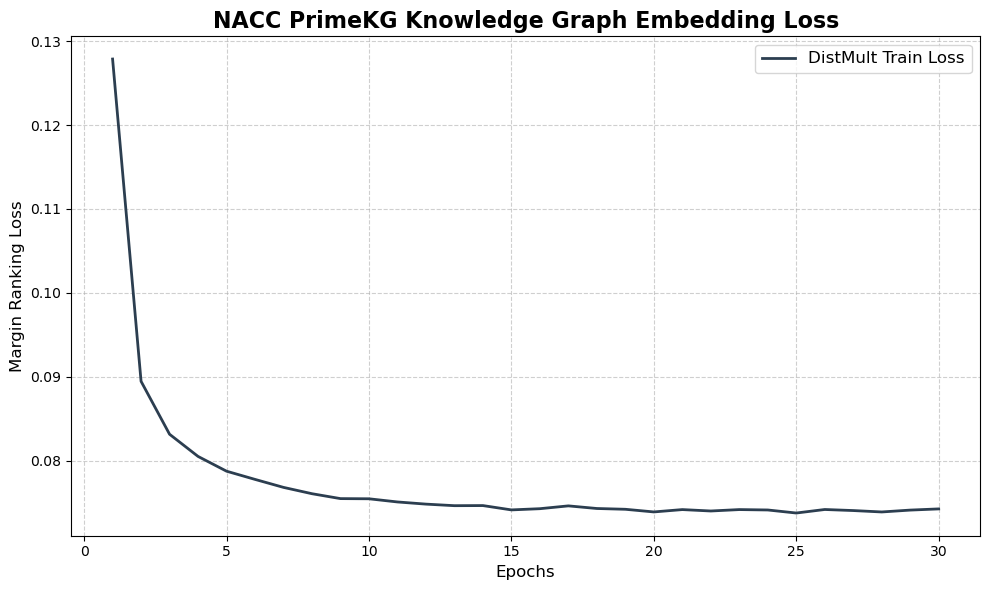

In [4]:
import pandas as pd
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import warnings
import os
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# ================= ⚡ 配置区 =================
# 将读取和输出的文件名全部替换为PrimeKG相关的命名
GRAPH_PATH = "NACC-PrimeKG-G.csv"
OUTPUT_ENT2ID = "NACC-PrimeKG-Entity2ID.json"
OUTPUT_REL2ID = "NACC-PrimeKG-Relation2ID.json"
OUTPUT_EMBED = "NACC-PrimeKG-Embeddings.npy"
OUTPUT_LOSS_HISTORY = "NACC-PrimeKG-LossHistory.json" 
OUTPUT_PLOT_PATH = "NACC-PrimeKG-LossCurve.png"

# 超参数设置 (保持与之前的实验完全一致)
EMBED_DIM = 128
NUM_EPOCHS = 30
BATCH_SIZE = 512
LR = 0.005
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ================= 1. 统计与索引构建 =================
def analyze_graph_and_build_dicts():
    print("==================================================")
    print("📊 步骤 1: 统计图谱规模并构建 ID 映射字典...")
    
    if not os.path.exists(GRAPH_PATH):
        raise FileNotFoundError(f"❌ 找不到图谱文件: {GRAPH_PATH}")
        
    df = pd.read_csv(GRAPH_PATH)
    
    entities = sorted(list(set(df['head'].unique()) | set(df['tail'].unique())))
    relations = sorted(list(df['relation'].unique()))
    
    entity2id = {ent: idx for idx, ent in enumerate(entities)}
    relation2id = {rel: idx for idx, rel in enumerate(relations)}
    
    with open(OUTPUT_ENT2ID, 'w', encoding='utf-8') as f:
        json.dump(entity2id, f, ensure_ascii=False, indent=4)
    with open(OUTPUT_REL2ID, 'w', encoding='utf-8') as f:
        json.dump(relation2id, f, ensure_ascii=False, indent=4)
        
    print(f"   📈 [PrimeKG 规模统计]:")
    print(f"      - 实体节点总数 (Entities): {len(entities)}")
    print(f"      - 关系类型总数 (Relations): {len(relations)}")
    print(f"      - 三元组边总数 (Triplets): {len(df)}")
    
    return df, entity2id, relation2id

# ================= 2. 数据集与模型定义 =================
class PureKGDataset(Dataset):
    def __init__(self, triplets_df, entity2id, relation2id):
        self.triplets = []
        for _, row in triplets_df.iterrows():
            h = entity2id[row['head']]
            r = relation2id[row['relation']]
            t = entity2id[row['tail']]
            self.triplets.append((h, r, t))
        self.triplets = torch.LongTensor(self.triplets)
        
    def __len__(self):
        return len(self.triplets)
    
    def __getitem__(self, idx):
        return self.triplets[idx]

class DistMult(nn.Module):
    def __init__(self, num_entities, num_relations, embed_dim):
        super(DistMult, self).__init__()
        self.num_entities = num_entities
        self.ent_emb = nn.Embedding(num_entities, embed_dim)
        self.rel_emb = nn.Embedding(num_relations, embed_dim)
        
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        self.criterion = nn.MarginRankingLoss(margin=1.0)

    def forward(self, h, r, t):
        h_e, r_e, t_e = self.ent_emb(h), self.rel_emb(r), self.ent_emb(t)
        return torch.sum(h_e * r_e * t_e, dim=1)

    def calculate_loss(self, h, r, t):
        batch_size = h.size(0)
        neg_t = torch.randint(0, self.num_entities, (batch_size,), device=h.device)
        pos_score = self.forward(h, r, t)
        neg_score = self.forward(h, r, neg_t)
        
        target = torch.ones(batch_size, device=h.device)
        return self.criterion(pos_score, neg_score, target)

# ================= 3. 训练主循环 =================
def train_kge():
    df, entity2id, relation2id = analyze_graph_and_build_dicts()
    
    print("\n==================================================")
    print(f"🚀 步骤 2: 启动 DistMult 模型训练 (设备: {DEVICE})...")
    
    dataset = PureKGDataset(df, entity2id, relation2id)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    model = DistMult(len(entity2id), len(relation2id), EMBED_DIM).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    loss_history = [] 
    
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        total_loss = 0
        
        for batch in dataloader:
            batch = batch.to(DEVICE)
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]
            
            optimizer.zero_grad()
            loss = model.calculate_loss(h, r, t)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        avg_loss = total_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        if epoch % 10 == 0 or epoch == 1:
            print(f"   - Epoch [{epoch:03d}/{NUM_EPOCHS}] | Train Loss: {avg_loss:.4f}")
            
    print("\n==================================================")
    print("💾 步骤 3: 提取并保存实体向量矩阵及 Loss 历史...")
    embeddings = model.ent_emb.weight.detach().cpu().numpy()
    np.save(OUTPUT_EMBED, embeddings)
    
    with open(OUTPUT_LOSS_HISTORY, 'w', encoding='utf-8') as f:
        json.dump(loss_history, f)
    
    print(f"   ✅ KGE 训练完成！")
    print(f"   📐 导出的向量矩阵形状: {embeddings.shape}")
    print(f"   📄 文件已保存至: {OUTPUT_EMBED} & {OUTPUT_LOSS_HISTORY}")
    print("==================================================")
    
    return loss_history

# ================= 4. 绘制Loss曲线 =================
def plot_loss_curve(losses):
    print("\n==================================================")
    print("📈 步骤 4: 正在绘制 KGE 训练 Loss 收敛曲线...")
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(losses) + 1), losses, color='#2c3e50', linewidth=2, label='DistMult Train Loss')
    
    plt.title('NACC PrimeKG Knowledge Graph Embedding Loss', fontsize=16, fontweight='bold')
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Margin Ranking Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    plt.savefig(OUTPUT_PLOT_PATH, dpi=300)
    print(f"   ✅ 曲线图已生成，已保存高清大图至: {OUTPUT_PLOT_PATH}")
    print("==================================================")
    plt.show()

if __name__ == "__main__":
    losses = train_kge()
    plot_loss_curve(losses)